Running the models through PCA dimensionality reduced TF-IDF tweets to address overfitting



In [1]:
##INITIALISATION CELL  - LOAD DATASET AND NECESSARY LIBRARIES 
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix 
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import numpy as np
from ast import literal_eval  # Import this module for parsing the string to a list
from sklearn import svm
from sklearn.svm import SVC 
import pickle
import lightgbm as lgb

#tfidf dataset - split into training and test (80% training and 20% test)
tfidf = pd.read_csv('pca_tfidf_tweets_dataset1')
tfidf2 = pd.read_csv('TF-IDF_vectorised_tweets.csv')
## ** SPLITTING TFIDF DATASET INTO TEST AND TRAIN VARIABLES ** ##

X = tfidf.drop(columns=['label']) # VECTORISED TWEET COLUMNS 
y = tfidf['label']   # TARGET LABEL --> DEPRESSED AND NON DEPRESSED
ED = tfidf2['ED_risk2']
SA = tfidf2['SA_risk2']
#X_TFIDF = X
# Splitting the data into train and test sets (80% train, 20% test)
X_trainTFIDF, X_testTFIDF, y_trainTFIDF, y_testTFIDF = train_test_split(X, y, test_size=0.2, random_state=42)

##tfidf sa and ed risk variables 
wider_depressive_symptoms = pd.concat([ED, SA],axis=1)
X_SA_ED = np.column_stack([X, wider_depressive_symptoms])
#X = pd.concat([vectorised_tweets, wider_depressive_symptoms],axis=1)
#target = tfidf['label'] 
#split test and train with addition ed and sa risk factors in the data
X_trainSA_ED, X_testSA_ED, y_trainSA_ED, y_testSA_ED = train_test_split(X_SA_ED, y, test_size=0.2, random_state=42)

LOGISTIC REGRESSION
* Classifier using TFIDF vectorisation (before hyperparamter tuning)
* Classifer using Word2Vec vectorisation (before hyperparamter tuning)
* Grid search
* Classifer using TFIDF vectorisation (after hyperparamter tuning)
* Classifer using Word2Vec vectorisation (after hyperparamter tuning)

In [3]:
logistic_regression_classifier = LogisticRegression()
logistic_regression_classifier.fit(X_trainTFIDF, y_trainTFIDF)
logreg_score = logistic_regression_classifier.score(X_testTFIDF, y_testTFIDF)
predictions = logistic_regression_classifier.predict(X_testTFIDF)

print("Logistic Regression Accuracy with TF-IDF vectorisation:", logreg_score)
#print classfication report for log reg classifier 
predictions = logistic_regression_classifier.predict(X_testTFIDF) 
print(classification_report(y_testTFIDF, predictions)) 


Logistic Regression Accuracy with TF-IDF vectorisation: 0.8204565408252853
              precision    recall  f1-score   support

           0       0.78      0.86      0.82      1073
           1       0.87      0.78      0.82      1205

    accuracy                           0.82      2278
   macro avg       0.82      0.82      0.82      2278
weighted avg       0.83      0.82      0.82      2278



In [2]:
logreg = LogisticRegression(C= 10, solver= 'liblinear')
# Train the model
logreg.fit(X_trainTFIDF, y_trainTFIDF)
# Predict on the test set
predictionsLogReg = logreg.predict(X_testTFIDF)

# Calculate accuracy
accuracy = accuracy_score(y_testTFIDF, predictionsLogReg)
#predictions = logreg.predict(X_testTFIDF) 
print(classification_report(y_testTFIDF, predictionsLogReg)) 
print("Logistic regression accuracy with tfidf vectorisation (AFTER hyperparamter tuning):", accuracy)
# saving model
logReg_file = 'logReg_model.sav'
pickle.dump(logreg, open(logReg_file, 'wb'))

              precision    recall  f1-score   support

           0       0.79      0.87      0.83      1073
           1       0.88      0.80      0.83      1205

    accuracy                           0.83      2278
   macro avg       0.83      0.84      0.83      2278
weighted avg       0.84      0.83      0.83      2278

Logistic regression accuracy with tfidf vectorisation (AFTER hyperparamter tuning): 0.8331870061457419


In [4]:
##confusion matrix
confusion = confusion_matrix(y_testTFIDF, predictionsLogReg)

confusion_df = pd.DataFrame(confusion, columns=["Predicted Label 0", "Predicted Label 1"], index=["Actual Label 0", "Actual Label 1"])
print(confusion_df)

                Predicted Label 0  Predicted Label 1
Actual Label 0                919                154
Actual Label 1                259                946


In [4]:
#print(tfidf.describe())


#fit the log reg model w/ tuned hyperparamters 
logreg = LogisticRegression(C= 10, solver= 'liblinear')
logreg.fit(X_trainSA_ED, y_trainSA_ED)

# predict on the test set
predictionsLogRegSAED = logreg.predict(X_testSA_ED)

# Calculate accuracy
accuracy = accuracy_score(y_testSA_ED, predictionsLogRegSAED)
#predictions = logreg.predict(X_testSA_ED) 
print(classification_report(y_testSA_ED, predictionsLogRegSAED)) 
print("Logistic regression accuracy with tfidf vectorisation (AFTER hyperparamter tuning) with SA and ED risk factor :", accuracy)

# saving model
logRegSA_ED_file = 'logRegSA_ED_model.sav'
pickle.dump(logreg, open(logRegSA_ED_file, 'wb'))

              precision    recall  f1-score   support

           0       0.80      0.87      0.84      1073
           1       0.88      0.81      0.84      1205

    accuracy                           0.84      2278
   macro avg       0.84      0.84      0.84      2278
weighted avg       0.84      0.84      0.84      2278

Logistic regression accuracy with tfidf vectorisation (AFTER hyperparamter tuning) with SA and ED risk factor : 0.839332748024583


In [5]:
##confusion matrix 
confusion = confusion_matrix(y_testTFIDF, predictionsLogRegSAED)

confusion_df = pd.DataFrame(confusion, columns=["Predicted Label 0", "Predicted Label 1"], index=["Actual Label 0", "Actual Label 1"])
print(confusion_df)

                Predicted Label 0  Predicted Label 1
Actual Label 0                936                137
Actual Label 1                229                976


RANDOM FOREST 
* Classifier using TFIDF vectorisation (before hyperparamter tuning)
* Classifer using Word2Vec vectorisation (before hyperparamter tuning)
* Grid search
* Classifer using TFIDF vectorisation (after hyperparamter tuning)
* Classifer using Word2Vec vectorisation (after hyperparamter tuning)

In [6]:
rf = RandomForestClassifier()
rf.fit(X_trainTFIDF, y_trainTFIDF)
rf_score = rf.score(X_testTFIDF, y_testTFIDF)
print("Random Forest Accuracy with TFIDF vectorisation (before hyperparamter tuning):", rf_score)
predictions = rf.predict(X_testTFIDF) 
print(classification_report(y_testTFIDF, predictions)) 


Random Forest Accuracy with TFIDF vectorisation (before hyperparamter tuning): 0.6931518876207199
              precision    recall  f1-score   support

           0       0.72      0.57      0.64      1073
           1       0.68      0.80      0.73      1205

    accuracy                           0.69      2278
   macro avg       0.70      0.69      0.69      2278
weighted avg       0.70      0.69      0.69      2278



In [8]:
rf = RandomForestClassifier(min_samples_split= 2, criterion='entropy', max_depth=None, n_estimators = 200)
rf.fit(X_trainTFIDF, y_trainTFIDF)
rf_score = rf.score(X_testTFIDF, y_testTFIDF)
predictions = rf.predict(X_testTFIDF) 
print(classification_report(y_testTFIDF, predictions)) 
print("Random Forest Accuracy with TFIDF vectorisation (after hyperparamter tuning):", rf_score)

              precision    recall  f1-score   support

           0       0.75      0.56      0.64      1073
           1       0.68      0.83      0.75      1205

    accuracy                           0.70      2278
   macro avg       0.71      0.69      0.69      2278
weighted avg       0.71      0.70      0.70      2278

Random Forest Accuracy with TFIDF vectorisation (after hyperparamter tuning): 0.7019315188762072


In [9]:
##rf with ED risk

rf = RandomForestClassifier(min_samples_split= 2, criterion='entropy', max_depth=None, n_estimators = 200)
rf.fit(X_trainSA_ED, y_trainSA_ED)
rf_score = rf.score(X_testSA_ED, y_testSA_ED)
predictions = rf.predict(X_testSA_ED) 
print(classification_report(y_testSA_ED, predictions)) 
print("Random Forest Accuracy with TFIDF vectorisation (after hyperparamter tuning) and ed and sa risk factors:", rf_score)

##confusion matrix 
confusion = confusion_matrix(y_testSA_ED, predictions)

confusion_df = pd.DataFrame(confusion, columns=["Predicted Label 0", "Predicted Label 1"], index=["Actual Label 0", "Actual Label 1"])
print(confusion_df)

              precision    recall  f1-score   support

           0       0.77      0.56      0.65      1073
           1       0.68      0.85      0.76      1205

    accuracy                           0.71      2278
   macro avg       0.72      0.70      0.70      2278
weighted avg       0.72      0.71      0.70      2278

Random Forest Accuracy with TFIDF vectorisation (after hyperparamter tuning) and ed and sa risk factors: 0.7111501316944688
                Predicted Label 0  Predicted Label 1
Actual Label 0                599                474
Actual Label 1                184               1021


SVM  
* Classifier using TFIDF vectorisation (before hyperparamter tuning)
* Classifer using Word2Vec vectorisation (before hyperparamter tuning)
* Grid search
* Classifer using TFIDF vectorisation (after hyperparamter tuning)
* Classifer using Word2Vec vectorisation (after hyperparamter tuning)

              precision    recall  f1-score   support

           0       0.80      0.86      0.83      1073
           1       0.87      0.81      0.84      1205

    accuracy                           0.83      2278
   macro avg       0.84      0.84      0.83      2278
weighted avg       0.84      0.83      0.83      2278

The best hyperparameters for logistic regression w2v classifier: {'C': 10, 'gamma': 1}


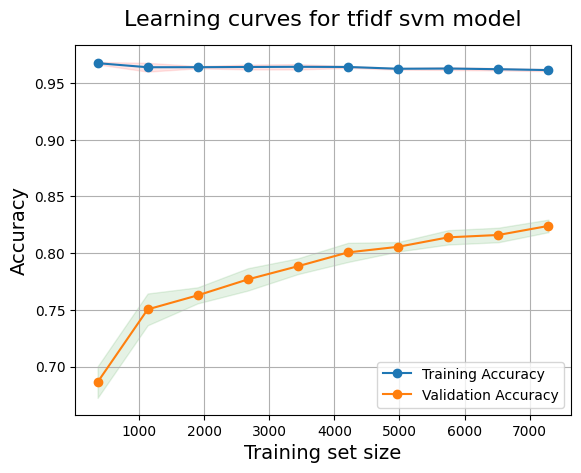

In [2]:
from sklearn.model_selection import learning_curve
#Hyperparamter tuning for tfidf svm model pcA
svm = SVC()
param_grid = {'C': [0.1, 1, 10, 100], # 0.1, 1.25 --5
              'gamma': [1, 0.1, 0.01, 0.001]
              }
grid = GridSearchCV(svm,param_grid)
#Fitting the model
grid.fit(X_trainTFIDF,y_trainTFIDF)
#Calculating the accuracy of tuned model
grid_svc = grid.predict(X_testTFIDF)
accuracy_score(y_testTFIDF,grid_svc)
#Classification report for the tuned model
print(classification_report(y_testTFIDF,grid_svc))
tfidfbest_svm = grid.best_estimator_
best_parameters = grid.best_params_
print("The best hyperparameters for logistic regression TFIDF classifier:", best_parameters)
##plot the learning curve, 
##plotting learning curve
import matplotlib.pyplot as plt
train_sizes = np.linspace(0.05, 1.0, 10) 


train_sizes, train_scores, validation_scores = learning_curve(estimator = tfidfbest_svm,X = X_trainTFIDF,y = y_trainTFIDF, train_sizes = train_sizes, cv = 5,scoring = 'accuracy')

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)
validation_scores_std = np.std(validation_scores, axis=1)
##showing learning curve with above vairables
plt.grid()

#shaded section showing the variability of training scores at each training set size --> done using std
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
#second does same but with test score line
plt.fill_between(train_sizes, validation_scores_mean - validation_scores_std,
                     validation_scores_mean + validation_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, label = 'Training Accuracy', marker='o')
plt.plot(train_sizes, validation_scores_mean, label = 'Validation Accuracy', marker='o')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves for tfidf svm model', fontsize = 16, y = 1.03)
plt.legend(loc='best')
plt.show()

In [3]:
#saving the model
SVM = 'SVM_model.sav'
pickle.dump(tfidfbest_svm, open(SVM, 'wb'))

In [7]:
#default values of svm 
model = SVC(kernel='rbf', gamma = 0.5, C=1)

# Train SVM 
model.fit(X_trainTFIDF, y_trainTFIDF)

# Make predictions on test set
y_pred = model.predict(X_testTFIDF)

# Evaluate accuracy
accuracy = np.mean(y_pred == y_testTFIDF) * 100
print("SVM classifer using TFIDF vectorisation before hyperparamter tuning: Classification Accuracy:", accuracy)
predictions = model.predict(X_testTFIDF) 
print(classification_report(y_testTFIDF, predictions)) 

SVM classifer using TFIDF vectorisation before hyperparamter tuning: Classification Accuracy: 82.9675153643547
              precision    recall  f1-score   support

           0       0.80      0.86      0.83      1073
           1       0.87      0.80      0.83      1205

    accuracy                           0.83      2278
   macro avg       0.83      0.83      0.83      2278
weighted avg       0.83      0.83      0.83      2278



In [8]:
#tuned model
model = SVC(kernel='rbf', gamma = 1, C=100)

# Train SVM 
model.fit(X_trainTFIDF, y_trainTFIDF)
# Make predictions on test set
svm_pred = model.predict(X_testTFIDF)

# Evaluate accuracy
accuracy = np.mean(svm_pred == y_testTFIDF) 
print("Classification Accuracy:", accuracy)
#predictions = model.predict(X_testTFIDF) 
print(classification_report(y_testTFIDF, svm_pred)) 
print("SVM accuracy with tfidf vectorisation (AFTER hyperparamter tuning) :", accuracy)


#saving the model
SVM = 'SVM_model.sav'
pickle.dump(model, open(SVM, 'wb'))

Classification Accuracy: 0.8345039508340649
              precision    recall  f1-score   support

           0       0.80      0.86      0.83      1073
           1       0.87      0.81      0.84      1205

    accuracy                           0.83      2278
   macro avg       0.84      0.84      0.83      2278
weighted avg       0.84      0.83      0.83      2278

SVM accuracy with tfidf vectorisation (AFTER hyperparamter tuning) : 0.8345039508340649


In [9]:
accuracy = np.mean(svm_pred == y_testTFIDF) * 100
print("Classification Accuracy:", accuracy)
#predictions = model.predict(X_testTFIDF) 
print(classification_report(y_testTFIDF, svm_pred)) 
print("SVM accuracy with tfidf vectorisation (AFTER hyperparamter tuning) :", accuracy)


#saving the model
SVM = 'SVM_model_PCA.sav'
pickle.dump(svm, open(SVM, 'wb'))

Classification Accuracy: 83.45039508340649
              precision    recall  f1-score   support

           0       0.80      0.86      0.83      1073
           1       0.87      0.81      0.84      1205

    accuracy                           0.83      2278
   macro avg       0.84      0.84      0.83      2278
weighted avg       0.84      0.83      0.83      2278

SVM accuracy with tfidf vectorisation (AFTER hyperparamter tuning) : 83.45039508340649


TypeError: cannot pickle 'module' object

In [10]:
##confusion matrix - svm
confusion = confusion_matrix(y_testTFIDF, svm_pred)

confusion_df = pd.DataFrame(confusion, columns=["Predicted 0", "Predicted 1"], index=["Actual 0", "Actual 1"])
print(confusion_df)

          Predicted 0  Predicted 1
Actual 0          927          146
Actual 1          231          974


In [11]:

#fit the log reg model w tuned hyperparamters 
svm = SVC(kernel='rbf', gamma = 1, C=100)

svm.fit(X_trainSA_ED, y_trainSA_ED)

# predict on the test set
predictions = svm.predict(X_testSA_ED)

# Calculate accuracy
accuracy = accuracy_score(y_testSA_ED, predictions)
#predictions = svm.predict(X_testSA_ED) 
print(classification_report(y_testSA_ED, predictions)) 
print("SVM accuracy with tfidf vectorisation (AFTER hyperparamter tuning) with ED and SA risk factor :", accuracy)

#saving the model
SVM_SA_ED = 'SVM_SA_ED_model.sav'
pickle.dump(svm, open(SVM_SA_ED, 'wb'))

##need to run
actual_labels = tfidf['label']
predicted_labels = svm.predict(X_testSA_ED)
confusion = confusion_matrix(actual_labels, predicted_labels)

confusion_df = pd.DataFrame(confusion, columns=["Predicted 0", "Predicted 1"], index=["Actual 0", "Actual 1"])
print(confusion_df)

              precision    recall  f1-score   support

           0       0.79      0.84      0.81      1073
           1       0.85      0.80      0.82      1205

    accuracy                           0.82      2278
   macro avg       0.82      0.82      0.82      2278
weighted avg       0.82      0.82      0.82      2278

SVM accuracy with tfidf vectorisation (AFTER hyperparamter tuning) with ED and SA risk factor : 0.820017559262511


ValueError: Found input variables with inconsistent numbers of samples: [11388, 2278]

LightGBM
* Default for w2v and tfidf
* gridsearch for optimal hyperparameter
* tuned for w2v and tfidf
* tuned with ed and sa risk factor 

[LightGBM] [Info] Number of positive: 4760, number of negative: 4350
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.042112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1402500
[LightGBM] [Info] Number of data points in the train set: 9110, number of used features: 5500
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522503 -> initscore=0.090072
[LightGBM] [Info] Start training from score 0.090072
LightGBM accuracy score with default values for tfidf:  0.752414398595259



<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

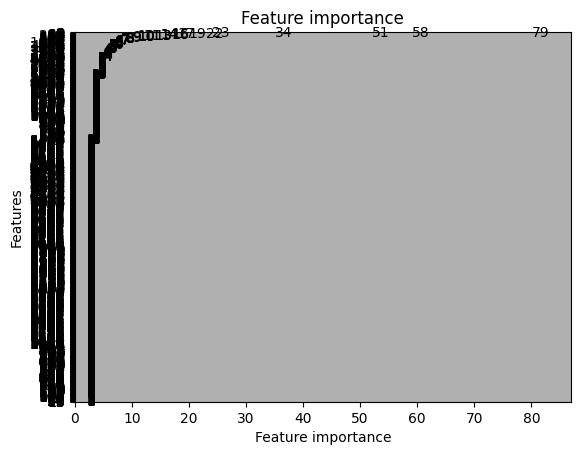

In [13]:
##lightgbm default with tfidf

lgbm = lgb.LGBMClassifier()
lgbm.fit(X_trainTFIDF,y_trainTFIDF)
lgbmPred = lgbm.predict(X_testTFIDF)
accuracy=accuracy_score(lgbmPred, y_testTFIDF)
print('LightGBM accuracy score with default values for tfidf: ', accuracy)
print()
cm = confusion_matrix(y_testTFIDF, lgbmPred)
lgb.plot_importance(lgbm)

In [14]:
##lightgbm tuned  with tfidf

lgbm = lgb.LGBMClassifier(boosting='DART', learning_rate=0.05, max_depth= 20, min_child_samples= 10, n_estimators= 300, num_leaves= 50)
lgbm.fit(X_trainTFIDF,y_trainTFIDF)
lgbmPred = lgbm.predict(X_testTFIDF)
accuracy=accuracy_score(lgbmPred, y_testTFIDF)
print('LightGBM accuracy score with default values for tfidf: ', accuracy)
print()
cm = confusion_matrix(y_testTFIDF, lgbmPred)
confusion_df = pd.DataFrame(cm, columns=["Predicted 0", "Predicted 1"], index=["Actual 0", "Actual 1"])
print(confusion_df)

[LightGBM] [Warning] boosting is set=DART, boosting_type=gbdt will be ignored. Current value: boosting=DART
[LightGBM] [Warning] boosting is set=DART, boosting_type=gbdt will be ignored. Current value: boosting=DART
[LightGBM] [Info] Number of positive: 4760, number of negative: 4350
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.882181 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1402500
[LightGBM] [Info] Number of data points in the train set: 9110, number of used features: 5500
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522503 -> initscore=0.090072
[LightGBM] [Info] Start training from score 0.090072
[LightGBM] [Warning] boosting is set=DART, boosting_type=gbdt will be ignored. Current value: boosting=DART
LightGBM accuracy score with default values for tfidf:  0.7581211589113257

          Predicted 0  Predicted 1
Actual 0          815          258
Actual 1          293          912


In [15]:
##lightgbm tuned  with tfidf with sa and ed risk factors 

lgbm = lgb.LGBMClassifier(boosting='DART', learning_rate=0.05, max_depth= 20, min_child_samples= 10, n_estimators= 300, num_leaves= 50)
lgbm.fit(X_trainSA_ED,y_trainSA_ED)
lgbmPred = lgbm.predict(X_testSA_ED)
accuracy=accuracy_score(lgbmPred, y_testSA_ED)
print('LightGBM accuracy score with tuned values for tfidf with SA and ED risk factors : ', accuracy)
print()
cm = confusion_matrix(y_testSA_ED, lgbmPred)
confusion_df = pd.DataFrame(cm, columns=["Predicted 0", "Predicted 1"], index=["Actual 0", "Actual 1"])
print(confusion_df)

[LightGBM] [Warning] boosting is set=DART, boosting_type=gbdt will be ignored. Current value: boosting=DART
[LightGBM] [Warning] boosting is set=DART, boosting_type=gbdt will be ignored. Current value: boosting=DART
[LightGBM] [Info] Number of positive: 4760, number of negative: 4350
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.951393 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1402504
[LightGBM] [Info] Number of data points in the train set: 9110, number of used features: 5502
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522503 -> initscore=0.090072
[LightGBM] [Info] Start training from score 0.090072
[LightGBM] [Warning] boosting is set=DART, boosting_type=gbdt will be ignored. Current value: boosting=DART
LightGBM accuracy score with tuned values for tfidf with SA and ED risk factors :  0.7532923617208077

          Predicted 0  Predicted 1
Actual 0          819          254
Actual 1 